# 12 — Exploring Latent Spaces and Interpolation in VAEs

## 📚 Learning Objectives

By completing this notebook, you will:
- Train a VAE and **map its latent space**: see that digit classes cluster without ever showing the model a label
- **Interpolate** between two real digits in latent space and decode the morph
- Sample the prior for novel digits — the three standard latent-space operations

## 🔗 Prerequisites

- ✅ Example 04 (VAE — the same architecture is trained here)
- ✅ Example 11 (sampling from trained models)

---

## Introduction

The latent space is *the* reason to use a VAE: a smooth, low-dimensional space where every point decodes to a plausible image. Three operations demonstrate that structure, and this notebook runs all three on a VAE you train:

1. **Visualization** — encode many images, project the latent vectors to 2-D, color by class
2. **Interpolation** — walk a straight line between two images' latent codes and decode each step
3. **Sampling** — decode random draws from the prior N(0, I)


In [1]:
# WHAT/WHY: train the example-04 VAE on MNIST (all ten classes) — the model
# whose latent space we then visualize, interpolate through, and sample.
import torch, torch.nn as nn, torch.nn.functional as F, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
LATENT = 16; BATCH = 128; EPOCHS = 6

# ── Data: 12,800 MNIST digits — small enough for CPU, varied enough to map ──
dataset = torchvision.datasets.MNIST('./data/mnist', train=True, download=True, transform=T.ToTensor())
subset  = torch.utils.data.Subset(dataset, range(12_800))
loader  = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# ── Model: encoder → (mu, logvar) → sampled z → decoder (example 04's VAE) ──
class VAE(nn.Module):
    def __init__(self, z=LATENT):
        super().__init__()
        self.enc    = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU())
        self.mu     = nn.Linear(256, z)
        self.logvar = nn.Linear(256, z)
        self.dec    = nn.Sequential(nn.Linear(z, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
    def encode(self, x):
        h = self.enc(x)
        return self.mu(h), self.logvar(h)
    def decode(self, z):
        return self.dec(z).view(-1, 1, 28, 28)
    def forward(self, x):
        mu, logvar = self.encode(x)
        # Reparameterization trick: sample z so gradients can flow through mu/logvar.
        z = mu + torch.exp(0.5 * logvar) * torch.randn_like(mu)
        return self.decode(z), mu, logvar

# ── Training: minimize reconstruction error + KL term (the ELBO) ──────────
vae = VAE(); opt = optim.Adam(vae.parameters(), lr=1e-3)
for epoch in range(EPOCHS):
    total = 0.0
    for x, _ in loader:
        recon, mu, logvar = vae(x)
        loss = (F.binary_cross_entropy(recon, x, reduction='sum')
                - 0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())) / x.size(0)
        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} — avg loss/image: {total/len(loader):.2f}")
vae.eval()


Epoch 1/6 — avg loss/image: 246.94


Epoch 2/6 — avg loss/image: 174.00


Epoch 3/6 — avg loss/image: 151.33


Epoch 4/6 — avg loss/image: 139.61


Epoch 5/6 — avg loss/image: 133.27


Epoch 6/6 — avg loss/image: 128.95


VAE(
  (enc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
  )
  (mu): Linear(in_features=256, out_features=16, bias=True)
  (logvar): Linear(in_features=256, out_features=16, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=16, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

## Operation 1 — Visualize the Latent Space

We encode 3,000 **test** digits (never seen in training), take their latent means μ, project the 16-D vectors to 2-D with PCA, and color each point by its true label — which the VAE never saw. Class clusters appearing anyway means the latent space organized itself around what digits *look like*.


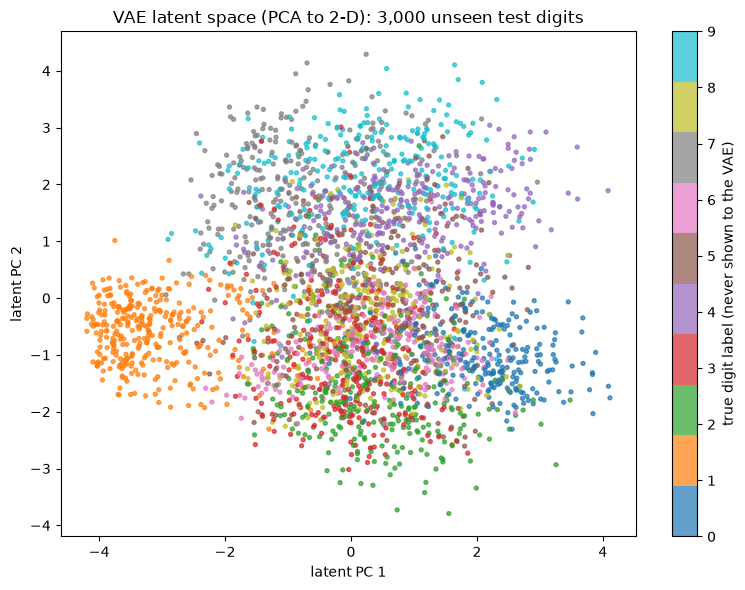

Same-colored points sitting together = the latent space grouped digits by
visual class on its own. Cluster overlap is normal for a small VAE —
similar-looking digits (e.g., 4/9) share latent territory.


In [2]:
# WHAT/WHY: encode unseen test digits and plot their latent vectors in 2-D,
# colored by true label — checking whether the latent space groups digits by
# class without ever having been given a label.
from sklearn.decomposition import PCA

test_ds = torchvision.datasets.MNIST('./data/mnist', train=False, transform=T.ToTensor())
imgs   = torch.stack([test_ds[i][0] for i in range(3000)])
labels = np.array([test_ds[i][1] for i in range(3000)])

# ── Encode: use the latent MEAN mu as each image's coordinates ────────────
with torch.no_grad():
    mu, _ = vae.encode(imgs)
z = mu.numpy()

# ── Project 16-D → 2-D with PCA for plotting ──────────────────────────────
z2 = PCA(n_components=2).fit_transform(z)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(z2[:, 0], z2[:, 1], c=labels, cmap='tab10', s=8, alpha=0.7)
plt.colorbar(sc, label='true digit label (never shown to the VAE)')
ax.set_title("VAE latent space (PCA to 2-D): 3,000 unseen test digits")
ax.set_xlabel("latent PC 1"); ax.set_ylabel("latent PC 2")
plt.tight_layout(); plt.show()

print("Same-colored points sitting together = the latent space grouped digits by")
print("visual class on its own. Cluster overlap is normal for a small VAE —")
print("similar-looking digits (e.g., 4/9) share latent territory.")


## Operation 2 — Interpolate Between Two Digits

Pick a real **3** and a real **8** from the test set, encode both to latent vectors z₁ and z₂, then decode points along the straight line z(α) = (1−α)·z₁ + α·z₂. Every intermediate point decodes to a plausible digit-like image — that smoothness is what the VAE's KL regularization bought us.


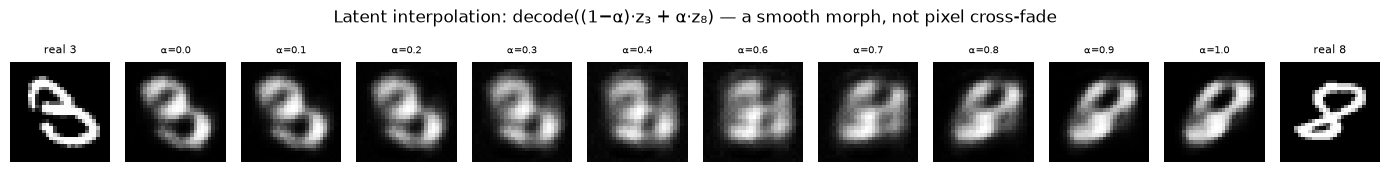

Compare with a PIXEL-space blend, which would show a ghostly double image;
the latent path instead passes through coherent digit shapes.


In [3]:
# WHAT/WHY: encode two real digits, walk the straight line between their
# latent codes, and decode each step — the classic latent-interpolation morph.

# ── Find a 3 and an 8 in the test set ─────────────────────────────────────
img_a = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 3)
img_b = next(test_ds[i][0] for i in range(1000) if test_ds[i][1] == 8)

# ── Encode both to their latent means ─────────────────────────────────────
with torch.no_grad():
    z_a, _ = vae.encode(img_a.unsqueeze(0))
    z_b, _ = vae.encode(img_b.unsqueeze(0))

# ── Decode 10 evenly spaced points along the line z_a → z_b ───────────────
steps = torch.linspace(0, 1, 10)
with torch.no_grad():
    morphs = torch.cat([vae.decode((1 - a) * z_a + a * z_b) for a in steps])

fig, axes = plt.subplots(1, 12, figsize=(14, 1.8))
axes[0].imshow(img_a.squeeze(), cmap='gray'); axes[0].set_title("real 3", fontsize=8); axes[0].axis('off')
for i in range(10):
    axes[i+1].imshow(morphs[i].squeeze(), cmap='gray'); axes[i+1].axis('off')
    axes[i+1].set_title(f"α={steps[i]:.1f}", fontsize=7)
axes[11].imshow(img_b.squeeze(), cmap='gray'); axes[11].set_title("real 8", fontsize=8); axes[11].axis('off')
plt.suptitle("Latent interpolation: decode((1−α)·z₃ + α·z₈) — a smooth morph, not pixel cross-fade")
plt.tight_layout(); plt.show()

print("Compare with a PIXEL-space blend, which would show a ghostly double image;")
print("the latent path instead passes through coherent digit shapes.")


## Operation 3 — Sample the Prior

Random z ~ N(0, I), decoded. (Example 11 covered sampling in depth; here it completes the latent-space toolkit.)


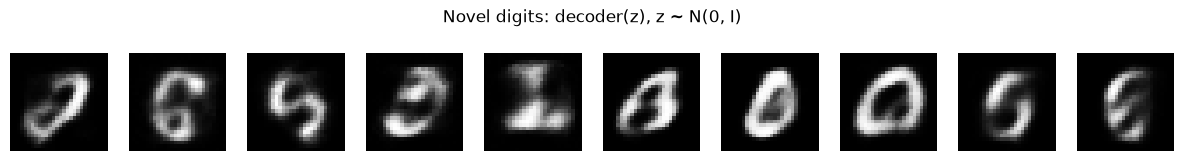

In [4]:
# WHAT/WHY: decode random draws from the prior — every point in latent space
# maps to some digit-like image, which is what makes the space explorable.
with torch.no_grad():
    samples = vae.decode(torch.randn(10, LATENT))


# Show the ten decoded samples in a row — each one is a brand-new digit.
fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for i, ax in enumerate(axes):
    ax.imshow(samples[i].squeeze(), cmap='gray'); ax.axis('off')
plt.suptitle("Novel digits: decoder(z), z ~ N(0, I)")
plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Papers:**
- Kingma & Welling (2014) — [Auto-Encoding Variational Bayes](https://arxiv.org/abs/1312.6114)
- White (2016) — [Sampling Generative Networks](https://arxiv.org/abs/1609.04468) *(interpolation done right, incl. spherical interpolation)*
- Higgins et al. (2017) — [β-VAE](https://openreview.net/forum?id=Sy2fchgcx) *(making latent dimensions interpretable)*
- Härkönen et al. (2020) — [GANSpace: Discovering Interpretable GAN Controls](https://arxiv.org/abs/2004.02546) *(PCA on latent space finds human-meaningful directions)*

**Looking ahead:** diffusion models — today's top image generators — are taught hands-on in **Unit 3, example 04**; their "latent space" is the noise process itself.


## 📝 Summary

In **12 — Exploring Latent Spaces and Interpolation** you ran the three standard latent-space operations on a VAE you trained: the 2-D map of 3,000 unseen digits showed class structure emerging without labels, the 3 → 8 interpolation decoded to a smooth morph through plausible digit shapes, and prior samples produced novel digits. This closes Unit 1's generative-fundamentals toolkit; Unit 2 applies generation to text, and Unit 3 (example 04) introduces diffusion models.
